# Ingest Fraser EFW data
This notebook pulls the Fraser Institute EFW dataset, standardizes columns,
and builds quinquennial extracts used throughout the rest of the pipeline.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path
from typing import Iterable

import pandas as pd
import requests
from IPython.display import display

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.paths import INTERMEDIATE_DIR, OUTPUT_DIR, QUINQUENNIAL_YEARS, RAW_DIR
from src.qc import assert_range, coverage_by_year
from src.viz_style import savefig, set_style

In [2]:
set_style()
raw_dir = RAW_DIR / "efw"
raw_dir.mkdir(parents=True, exist_ok=True)

EFW_URLS = [
    "https://www.fraserinstitute.org/sites/default/files/efw-2023-master-index-data-for-researchers.xlsx",
    "https://www.fraserinstitute.org/sites/default/files/efw-2022-master-index-data-for-researchers.xlsx",
    "https://www.fraserinstitute.org/sites/default/files/efw-2021-master-index-data-for-researchers.xlsx",
]


def _download_file(url: str, dest: Path) -> bool:
    try:
        resp = requests.get(url, timeout=30)
        if resp.status_code != 200:
            return False
        dest.write_bytes(resp.content)
        return True
    except requests.RequestException:
        return False


def _find_header_row(path: Path, sheet_name: str | int | None = None) -> int:
    preview = pd.read_excel(path, header=None, nrows=10, sheet_name=sheet_name)
    if isinstance(preview, dict):
        preview = list(preview.values())[0]
    for idx, row in preview.iterrows():
        values = [str(v).strip() for v in row.values]
        if "Year" in values and any("ISO" in v for v in values):
            return idx
    return 0


def _standardize_columns(columns: Iterable[str]) -> list[str]:
    cleaned = []
    for col in columns:
        col_str = str(col).strip()
        col_str = col_str.replace(" ", "_").replace("/", "_").replace("-", "_")
        col_str = col_str.replace("(", "").replace(")", "")
        col_str = col_str.replace("&", "and")
        cleaned.append(col_str.lower())
    return cleaned


def _select_column(df: pd.DataFrame, candidates: list[str]) -> str | None:
    for col in df.columns:
        if col in candidates:
            return col
    return None

In [3]:
source_file = raw_dir / "efw_master.xlsx"
if not source_file.exists():
    for url in EFW_URLS:
        if _download_file(url, source_file):
            break

if not source_file.exists():
    candidates = list(raw_dir.glob("*.xlsx")) + list(raw_dir.glob("*.csv"))
    legacy_dir = ROOT / "data" / "raw" / "efw"
    legacy_candidates = list(legacy_dir.glob("*.xlsx")) + list(legacy_dir.glob("*.csv"))
    alt = ROOT / "data" / "fraser.xlsx"
    if alt.exists():
        source_file = alt
    elif candidates:
        source_file = candidates[0]
    elif legacy_candidates:
        source_file = legacy_candidates[0]
    else:
        raise FileNotFoundError(
            "EFW dataset not found in data/01_raw/efw/, data/raw/efw/, or data/fraser.xlsx"
        )

if source_file.suffix.lower() == ".csv":
    df = pd.read_csv(source_file)
else:
    header_row = _find_header_row(source_file, sheet_name=0)
    df = pd.read_excel(source_file, header=header_row, sheet_name=0)

df.columns = _standardize_columns(df.columns)

iso_col = _select_column(df, ["iso_code", "iso_code3", "iso3", "iso"])
year_col = _select_column(df, ["year"])

overall_col = None
for col in df.columns:
    if "economic_freedom_all_areas" in col or col == "efw":
        overall_col = col
        break

area_cols = {}
for col in df.columns:
    if col.startswith("area_1") and "size_of_government" in col:
        area_cols["efw_area1"] = col
    if col.startswith("area_2") and "with_gender_adjustment" in col:
        area_cols["efw_area2"] = col
    if col.startswith("area_2") and "without_gender_adjustment" in col and "efw_area2" not in area_cols:
        area_cols["efw_area2"] = col
    if col.startswith("area_3") and "sound_money" in col:
        area_cols["efw_area3"] = col
    if col.startswith("area_4") and "freedom_to_trade_internationally" in col:
        area_cols["efw_area4"] = col
    if col.startswith("area_5") and "regulation" in col:
        area_cols["efw_area5"] = col

if iso_col is None or year_col is None or overall_col is None:
    raise ValueError("Unable to identify required columns in EFW dataset.")

keep_cols = [iso_col, year_col, overall_col] + list(area_cols.values())
raw = df[keep_cols].copy()
raw = raw.rename(
    columns={
        iso_col: "iso3c",
        year_col: "year",
        overall_col: "efw_summary",
        **{v: k for k, v in area_cols.items()},
    }
)
raw["iso3c"] = raw["iso3c"].astype(str).str.upper().str.strip()
raw["year"] = pd.to_numeric(raw["year"], errors="coerce")
raw = raw.dropna(subset=["iso3c", "year"])
raw["year"] = raw["year"].astype(int)
raw = raw[raw["iso3c"].str.len() == 3]

raw_path = RAW_DIR / "efw_normalized.parquet"
raw.to_parquet(raw_path, index=False)

quin = raw[raw["year"].isin(QUINQUENNIAL_YEARS)].copy()
quin = quin.drop_duplicates(subset=["iso3c", "year"]).sort_values(["iso3c", "year"])

INTERMEDIATE_DIR.mkdir(parents=True, exist_ok=True)
quin_path = INTERMEDIATE_DIR / "efw_quinquennial.parquet"
quin.to_parquet(quin_path, index=False)

assert_range(quin, "efw_summary", min_value=0, max_value=10)

summary = pd.DataFrame(
    {
        "rows": [len(raw)],
        "countries": [raw["iso3c"].nunique()],
        "years": [raw["year"].nunique()],
        "min_year": [raw["year"].min()],
        "max_year": [raw["year"].max()],
    }
)
display(summary.style.set_caption("EFW normalized dataset coverage"))
display(raw.head(10).style.set_caption("Sample of normalized EFW data"))

,rows,countries,years,min_year,max_year
0,4950,165,30,1970,2023


,iso3c,year,efw_summary,efw_area1,efw_area2,efw_area3,efw_area4,efw_area5
0,HKG,2023,8.550000,7.490583,7.597247,9.531846,9.661213,8.489994
1,SGP,2023,8.500000,7.544422,8.580663,8.594668,9.560131,8.203942
2,NZL,2023,8.330000,6.358088,8.731138,8.985730,8.942067,8.654086
3,CHE,2023,8.280000,7.691266,8.308350,9.583964,8.138636,7.691329
4,USA,2023,8.100000,7.245873,7.589723,9.018852,8.110827,8.514848
5,IRL,2023,8.050000,6.419319,7.927054,8.867781,8.995318,8.057838
6,AUS,2023,8.030000,6.212278,8.684688,8.868105,8.152498,8.221932
7,TWN,2023,8.030000,7.755755,7.525330,9.489741,8.160646,7.226754
8,DNK,2023,8.020000,5.407028,8.883013,9.048527,8.950573,7.821602
9,NLD,2023,7.970000,5.252076,8.932912,9.231795,9.163180,7.249059


In [4]:
coverage = coverage_by_year(quin, "year", ["efw_summary"]).rename(
    columns={"efw_summary": "n_countries"}
)
coverage_path = OUTPUT_DIR / "tables" / "efw_coverage_by_year.csv"
coverage_path.parent.mkdir(parents=True, exist_ok=True)
coverage.to_csv(coverage_path, index=False)
display(coverage.style.set_caption("EFW quinquennial coverage by year"))

meta = {
    "source_file": str(source_file),
    "raw_normalized": str(raw_path),
    "efw_scale": "0-10",
    "variables": ["efw_summary"] + sorted(area_cols.keys()),
    "coverage_by_year": coverage.to_dict(orient="records"),
}
meta_path = INTERMEDIATE_DIR / "efw_metadata.json"
meta_path.write_text(json.dumps(meta, indent=2))

,year,n_countries
0,1970,98
1,1975,107
2,1980,110
3,1985,114
4,1990,117
5,1995,123
6,2000,158
7,2005,161
8,2010,162
9,2015,162


1016

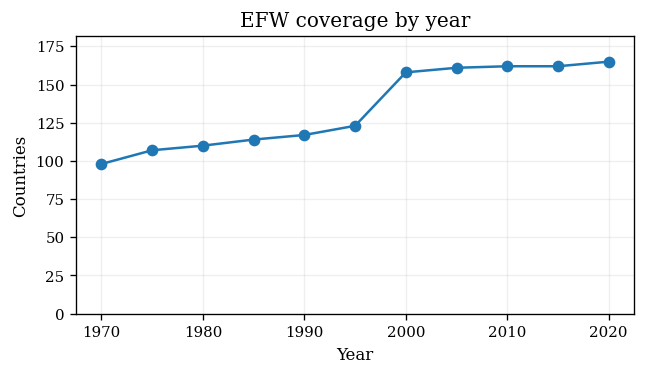

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(coverage["year"], coverage["n_countries"], marker="o")
ax.set_title("EFW coverage by year")
ax.set_xlabel("Year")
ax.set_ylabel("Countries")
ax.set_ylim(0, coverage["n_countries"].max() * 1.1)

display(fig)
savefig(fig, OUTPUT_DIR / "figures" / "coverage" / "efw_coverage_by_year")
plt.close(fig)

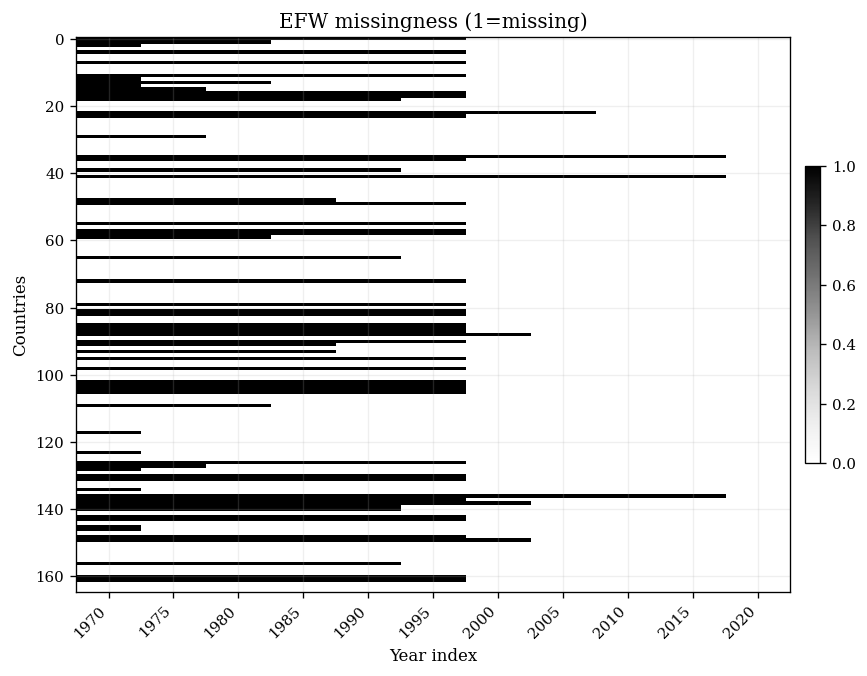

In [6]:
heat = quin.pivot_table(index="iso3c", columns="year", values="efw_summary", aggfunc="mean")
missing = heat.isna().astype(int)
fig, ax = plt.subplots(figsize=(8, 6))
img = ax.imshow(missing, aspect="auto", interpolation="nearest", cmap="Greys")
ax.set_title("EFW missingness (1=missing)")
ax.set_xlabel("Year index")
ax.set_ylabel("Countries")
ax.set_xticks(range(len(heat.columns)))
ax.set_xticklabels(heat.columns, rotation=45, ha="right")
fig.colorbar(img, ax=ax, fraction=0.02, pad=0.02)

display(fig)
savefig(fig, OUTPUT_DIR / "figures" / "coverage" / "efw_missingness_heatmap")
plt.close(fig)

## Interpretation
The Fraser EFW data provide a broad panel of country-year observations.
Coverage rises from 98 countries in 1970 to 165 countries by 2020, and the
missingness heatmap shows that gaps are concentrated in earlier periods and
a smaller subset of countries. This supports using the quinquennial grid for
consistent coverage in downstream analysis.